# Larissa CMIP6 SSP5-8.5 Projection EDA (2026-2045)

Applies the same processing and indicator-calculation pipeline used in `seville_cmip6_projection_eda.ipynb`
to the CMIP6 `cmcc_esm2` SSP5-8.5 projection pulled by `pull_cmip6_projections.py` for Larissa, with the
indicator set adapted to match `larissa_era5_eda.ipynb`/`Climate_Indicators_Modeling_Larissa.ipynb`'s own
findings rather than Seville's. Larissa's headline story is different by design (see
`Climate_Indicators_Modeling_Larissa.ipynb`'s intro): **`tmin_mean`** (chronic nighttime warming --
Larissa warms at night too, unlike Seville), **`precip_scaled`** (aggregate wet intensification, not
drying), and **`max_week_precip_mm`** (single-event flood-peak intensity, e.g. Storm Daniel Sep 2023) --
deliberately **excluding** `min_spi3`/drought, which that notebook's section 10.5/10.6 already
established is flat-to-improving and uncorrelated with Larissa's flood side, so it no longer belongs in
the "what's intensifying" story the way it does for Seville.

**Source data:** `data/larissa_cmip6_ssp585_2026_2045.csv` (model `cmcc_esm2`, experiment `ssp5_8_5`,
grid points in the Larissa bounding box, 2026-01-01 to 2045-12-31).

**Historical reference** (for fixed thresholds and the ERA5-vs-projection comparison):
`eda_results/eda_outputs_larissa/larissa_daily.csv`, `annual_summary.csv`, and
`larissa_climate_indicators_annual.csv`, from `larissa_era5_eda.ipynb` and
`Climate_Indicators_Modeling_Larissa.ipynb`.

**Known limitations, stated once here rather than repeated throughout:** raw (non-bias-corrected)
CMIP6 output at a single grid box, one model, one scenario -- see
`documentation/projection_data_pull_plan.md` Step 6 and `project_summary.md`'s "illustrative of
directional risk rather than definitive climate-model consensus" framing. Sections 1-11 work
entirely with raw output; Section 12 applies an Equidistant CDF Matching bias correction, and
Sections 13-16 recompute every indicator (heatwaves, hot days, wet-day stats, trends,
`max_week_precip_mm`) on that corrected series with an explicit before/after comparison. Full
breakdown of what carries over vs. what doesn't (or what's new here vs. Seville's version) is in
Section 17 below.


In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
from scipy import stats
import matplotlib.pyplot as plt

pd.set_option("display.width", 120)

RAW_CSV = Path("data/larissa_cmip6_ssp585_2026_2045.csv")
ERA5_DAILY_CSV = Path("eda_results/eda_outputs_larissa/larissa_daily.csv")
ERA5_ANNUAL_CSV = Path("eda_results/eda_outputs_larissa/annual_summary.csv")
ERA5_INDICATORS_CSV = Path("eda_results/eda_outputs_larissa/larissa_climate_indicators_annual.csv")
OUT = Path("eda_results/eda_outputs_larissa_projection")
OUT.mkdir(parents=True, exist_ok=True)

# Fixed reference period -- used only to fit thresholds below, never refit on new data.
# See fixed_reference_period_principle.md.
REFERENCE_START, REFERENCE_END = 1990, 2020


## 1. Load the raw CMIP6 pull

Identical QC step to `seville_cmip6_projection_eda.ipynb` Section 1 -- `pull_cmip6_projections.py`
merges 7 separately-downloaded variables on `(valid_time, lat, lon)`, each carrying its own 2-valued
`bnds` dimension that isn't part of the merge key. Dropped explicitly below, as a documented QC step
(same reasoning as Seville's version -- not repeated here).


In [2]:
raw = pd.read_csv(RAW_CSV, parse_dates=["valid_time"])
print(f"raw shape: {raw.shape}")
print(raw.columns.tolist())

BNDS_COLS = ["bnds", "time_bnds", "lat_bnds", "lon_bnds", "height"]
df = raw.drop(columns=[c for c in BNDS_COLS if c in raw.columns]).drop_duplicates().reset_index(drop=True)

n_days = df["valid_time"].nunique()
n_points = df[["lat", "lon"]].drop_duplicates().shape[0]
print(f"deduped shape: {df.shape}  (expected {n_days} days x {n_points} grid points = {n_days * n_points})")
assert df.shape[0] == n_days * n_points, "dedup did not fully resolve the bnds cross-join"
df.head()


raw shape: (43800, 12)
['valid_time', 'lat', 'lon', 'tas', 'tasmax', 'tasmin', 'pr', 'huss', 'sfcWind', 'psl', 'precip_mm_day', 'relative_humidity_pct']
deduped shape: (43800, 12)  (expected 7300 days x 6 grid points = 43800)


,valid_time,lat,lon,tas,tasmax,tasmin,pr,huss,sfcWind,psl,precip_mm_day,relative_humidity_pct
0,2026-01-01,39.109948,21.25,285.14886,287.24734,282.10650,0.000038,0.007378,3.348794,101718.530,3.275996,85.803510
1,2026-01-01,39.109948,22.50,283.18210,286.87910,279.02496,0.000024,0.006422,2.569562,101682.860,2.077823,85.110886
2,2026-01-01,39.109948,23.75,287.32016,288.40366,286.01852,0.000017,0.006839,6.612102,101495.920,1.469148,68.901400
3,2026-01-01,40.052356,21.25,283.02188,285.72100,279.47134,0.000036,0.006797,2.340005,101617.914,3.072422,90.974625
4,2026-01-01,40.052356,22.50,281.51715,285.19296,277.58362,0.000030,0.005924,2.501745,101599.984,2.587445,87.770325


## 2. Physical plausibility check

Same bounds as Seville's version -- these are CMIP6-native ranges (Kelvin temperatures, flux-unit
precip, Pa pressure), not city-specific, so they carry over unchanged.


In [3]:
BOUNDS = {
    "tas": (250, 325), "tasmax": (250, 330), "tasmin": (245, 320),
    "pr": (0, 0.005),           # kg m-2 s-1 -- 0.005 corresponds to ~430 mm/day, a generous upper bound
    "huss": (0, 0.03),
    "sfcWind": (0, 40),
    "psl": (90000, 108000),
    "precip_mm_day": (0, 400),
    "relative_humidity_pct": (0, 100),
}
for col, (lo, hi) in BOUNDS.items():
    if col not in df.columns:
        continue
    n_bad = (~df[col].between(lo, hi)).sum()
    print(f"{col:24s} range=({df[col].min():.4g}, {df[col].max():.4g})  out-of-bounds={n_bad}")

# precip_mm_day carries tiny floating-point negative noise from the flux conversion at near-zero
# rainfall -- clip rather than treat it as a QC failure (same artifact documented in Seville's
# version of this check).
df["precip_mm_day"] = df["precip_mm_day"].clip(lower=0)


tas                      range=(262.1, 313.8)  out-of-bounds=0
tasmax                   range=(267.9, 320.4)  out-of-bounds=0
tasmin                   range=(258.8, 307.1)  out-of-bounds=0
pr                       range=(-2.679e-20, 0.000688)  out-of-bounds=54
huss                     range=(0.001445, 0.0216)  out-of-bounds=0
sfcWind                  range=(0.3013, 18)  out-of-bounds=0
psl                      range=(9.888e+04, 1.047e+05)  out-of-bounds=0
precip_mm_day            range=(-2.315e-15, 59.44)  out-of-bounds=54
relative_humidity_pct    range=(7.371, 100)  out-of-bounds=0


## 3. Unit conversions

Same `- 273.15` Kelvin-to-Celsius conversion as Seville. Precipitation, specific humidity, wind
speed, and relative humidity are already in final units/derived form upstream.


In [4]:
df["tas_c"] = df["tas"] - 273.15
df["tasmax_c"] = df["tasmax"] - 273.15
df["tasmin_c"] = df["tasmin"] - 273.15
df[["tas_c", "tasmax_c", "tasmin_c"]].describe()


,tas_c,tasmax_c,tasmin_c
count,43800.000000,43800.000000,43800.000000
mean,18.052091,21.342775,14.648217
std,8.813632,9.513503,8.394741
min,-11.001260,-5.200700,-14.366340
25%,11.216723,13.907783,8.285775
50%,16.933400,19.853955,14.061920
75%,25.652185,29.061203,21.739380
max,40.659200,47.256770,33.971430


## 4. Grid-point averaging (grid points to 1 daily series)

Same unweighted arithmetic mean as Seville's version, and the same discipline of recomputing RH from
grid-averaged `tas`/`huss`/`psl` (Magnus-formula) rather than averaging RH directly.


In [5]:
BASE = ["tas", "tasmax", "tasmin", "tas_c", "tasmax_c", "tasmin_c",
        "precip_mm_day", "sfcWind", "huss", "psl"]

lar = df.groupby("valid_time")[BASE].mean()

def derive_rh(tas_k, huss, psl_pa):
    """Identical formula to pull_cmip6_projections.py's per-grid-point derivation, applied here
    to the grid-averaged base variables instead."""
    t_c = tas_k - 273.15
    p_hpa = psl_pa / 100.0
    q = huss
    vapor_pressure = q * p_hpa / (0.622 + 0.378 * q)
    sat_vapor_pressure = 6.112 * np.exp(17.62 * t_c / (243.12 + t_c))
    return np.clip(100 * vapor_pressure / sat_vapor_pressure, 0, 100)

lar["relative_humidity_pct"] = derive_rh(lar["tas"], lar["huss"], lar["psl"])
lar.head()


,tas,tasmax,tasmin,tas_c,tasmax_c,tasmin_c,precip_mm_day,sfcWind,huss,psl,relative_humidity_pct
valid_time,,,,,,,,,,,
2026-01-01,284.340463,286.744193,281.431862,11.190463,13.594193,8.281862,2.381233,3.847046,0.006627,101584.856333,81.227959
2026-01-02,281.503765,284.188678,279.805023,8.353765,11.038678,6.655023,0.055710,4.704055,0.003797,102533.065000,56.894695
2026-01-03,283.280193,286.790063,280.258402,10.130193,13.640063,7.108402,0.000031,3.952796,0.005444,102601.428500,72.371472
2026-01-04,283.733245,285.738548,281.337712,10.583245,12.588548,8.187712,0.009806,2.377612,0.005653,102503.267667,72.830348
2026-01-05,284.023330,285.890265,282.400213,10.873330,12.740265,9.250213,0.001154,2.672772,0.006085,102174.875500,76.637166


## 5. Daily frame

Same as Seville: CMIP6 provides true daily `tasmax`/`tasmin` natively, so `lar` (indexed by
`valid_time`, one row per day) *is* the daily frame -- no resampling step. Columns renamed to match
`larissa_era5_eda.ipynb`'s naming convention.

Same caveat as Seville's version applies: `heat_index_c` here is computed once per day from daily-mean
T/RH, not (as in the ERA5 pipeline) the max of intra-day samples -- named differently from the
historical `heat_index_max_c` for that reason.


In [6]:
def compute_heat_index(t_c, rh):
    """Identical NWS Rothfusz fit used throughout the project (degF internally, converted back to degC)."""
    t_f = t_c * 9 / 5 + 32
    simple = 0.5 * (t_f + 61.0 + (t_f - 68.0) * 1.2 + rh * 0.094)
    hi_f = (-42.379 + 2.04901523 * t_f + 10.14333127 * rh - 0.22475541 * t_f * rh - 6.83783e-3 * t_f**2
            - 5.481717e-2 * rh**2 + 1.22874e-3 * t_f**2 * rh + 8.5282e-4 * t_f * rh**2 - 1.99e-6 * t_f**2 * rh**2)
    return (np.where(t_f < 80, simple, hi_f) - 32) * 5 / 9

daily = pd.DataFrame({
    "tmax_c": lar["tasmax_c"],
    "tmin_c": lar["tasmin_c"],
    "tmean_c": lar["tas_c"],
    "precip_mm_day": lar["precip_mm_day"],
    "wind_avg": lar["sfcWind"],
    "rh_mean_percent": lar["relative_humidity_pct"],
})
daily["dtr_c"] = daily["tmax_c"] - daily["tmin_c"]
daily["heat_index_c"] = compute_heat_index(daily["tmean_c"], daily["rh_mean_percent"])
daily["year"] = daily.index.year
daily["month"] = daily.index.month

daily.to_csv(OUT / "larissa_projection_daily.csv")
daily.describe()


,tmax_c,tmin_c,tmean_c,precip_mm_day,wind_avg,rh_mean_percent,dtr_c,heat_index_c,year,month
count,7300.000000,7300.000000,7300.000000,7300.000000,7300.000000,7300.000000,7300.000000,7300.000000,7300.000000,7300.000000
mean,21.342775,14.648217,18.052091,1.263902,2.881795,61.097001,6.694557,17.441348,2035.500000,6.526027
std,9.283176,8.003814,8.650636,3.073207,1.002325,17.971241,2.098208,9.064495,5.766676,3.448088
min,-0.974935,-5.890012,-3.527175,0.000000,0.855969,23.495949,1.194963,-5.967240,2026.000000,1.000000
25%,13.889108,8.380932,11.202993,0.000398,2.134821,45.627414,5.232918,10.351994,2030.750000,4.000000
50%,19.950751,13.670372,16.788053,0.083133,2.700593,63.094603,6.791628,16.319005,2035.500000,7.000000
75%,29.689993,21.783831,25.843499,0.871766,3.442176,75.589714,8.272692,25.697231,2040.250000,10.000000
max,42.843670,32.746643,37.773350,39.949454,9.174075,100.000000,12.427747,37.955532,2045.000000,12.000000


## 6. Fixed reference-period thresholds (loaded from ERA5, 1990-2020, never refit here)

Same reasoning as Seville Section 6: the P90 heatwave threshold is computed once from Larissa's own
ERA5 historical daily series, restricted to the fixed 1990-2020 reference period, and never refit on
projection data (`fixed_reference_period_principle.md`).


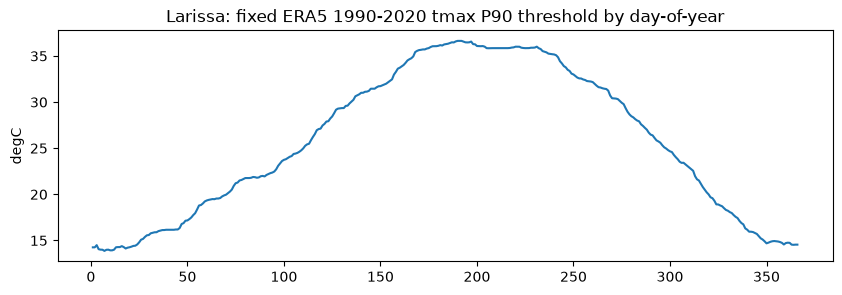

In [7]:
era5_daily = pd.read_csv(ERA5_DAILY_CSV, parse_dates=["valid_time"])
era5_daily["year"] = era5_daily["valid_time"].dt.year
ref = era5_daily[era5_daily["year"].between(REFERENCE_START, REFERENCE_END)].copy()
ref["doy"] = ref["valid_time"].dt.dayofyear

tmax_p90_by_doy = {}
for doy in range(1, 367):
    window = [((doy - 1 + k) % 366) + 1 for k in range(-7, 8)]
    tmax_p90_by_doy[doy] = ref.loc[ref["doy"].isin(window), "tmax_c"].quantile(0.90)

pd.Series(tmax_p90_by_doy).plot(
    title="Larissa: fixed ERA5 1990-2020 tmax P90 threshold by day-of-year", figsize=(10, 3))
plt.ylabel("degC")
plt.show()


## 7. Indicator calculation

Same fixed thresholds and >=3-consecutive-day heatwave-run requirement as Seville's version.


In [8]:
THRESH = [30, 33, 35, 37, 40]

d = daily.copy()
d["doy"] = d.index.dayofyear
d["tmax_p90"] = d["doy"].map(tmax_p90_by_doy)
d["exceed"] = d["tmax_c"] > d["tmax_p90"]

grp = (d["exceed"] != d["exceed"].shift()).cumsum()
runs = (d[d["exceed"]]
        .groupby(grp[d["exceed"]])
        .agg(start=("tmax_c", lambda s: s.index.min()),
             length=("tmax_c", "size"),
             peak=("tmax_c", "max"),
             mean_tmax=("tmax_c", "mean")))
heatwaves = runs[runs["length"] >= 3].reset_index(drop=True)
heatwaves["year"] = pd.to_datetime(heatwaves["start"]).dt.year
heatwaves.to_csv(OUT / "larissa_projection_heatwave_events.csv", index=False)

hot = pd.DataFrame({
    f"days tmax>={t} C": d.groupby("year")["tmax_c"].apply(lambda s, t=t: (s >= t).sum())
    for t in THRESH
})
hot["tropical nights tmin>=20 C"] = d.groupby("year")["tmin_c"].apply(lambda s: int((s >= 20).sum()))
hot["days heat index>=35 C"] = d.groupby("year")["heat_index_c"].apply(lambda s: int((s >= 35).sum()))

hw_year = heatwaves.groupby("year").agg(
    heatwaves=("length", "size"),
    **{"heatwave days": ("length", "sum"), "longest (days)": ("length", "max")},
)

print(f"{len(heatwaves)} heatwave events detected, {heatwaves['year'].nunique()} distinct years")
hot.tail()


96 heatwave events detected, 19 distinct years


,days tmax>=30 C,days tmax>=33 C,days tmax>=35 C,days tmax>=37 C,days tmax>=40 C,tropical nights tmin>=20 C,days heat index>=35 C
year,,,,,,,
2041,87,67,49,21,1,110,1
2042,92,70,46,15,1,115,2
2043,88,63,45,28,4,108,4
2044,113,81,54,43,13,126,13
2045,98,48,30,10,0,121,4


## 8. Wet-day and precipitation extremes, including `max_week_precip_mm`

Same wet-day/dry-spell logic as Seville's version, **plus one addition Seville's pipeline never
needed**: `max_week_precip_mm` (annual maximum single-week precipitation total) -- Larissa's
flood-intensity indicator, identical construction to `Calculating_SPI_for_Larissa.ipynb` Section 6
(`precip_mm_day`, resampled to weekly sums, then the annual max, labeled by the year the week falls
in), just applied to the CMIP6 daily series instead of ERA5's.


In [9]:
WET = 1.0
d["is_wet"] = d["precip_mm_day"] >= WET

def max_dry_run(is_wet):
    dry_flag = (~is_wet).astype(int)
    run_id = (is_wet != is_wet.shift()).cumsum()
    return int(dry_flag.groupby(run_id).sum().max())

def annual_max_week_precip(frame, precip_col="precip_mm_day"):
    """Same construction as Calculating_SPI_for_Larissa.ipynb Section 6: weekly-resampled sum,
    then the annual max, labeled by the calendar year the week falls in."""
    weekly = frame[precip_col].resample("W").sum()
    weekly_year = weekly.index.to_series().apply(lambda ts: ts.year)
    return weekly.groupby(weekly_year).max().rename("max_week_precip_mm").rename_axis("year")

wetstats = d.groupby("year").apply(lambda g: pd.Series({
    "wet days": int(g["is_wet"].sum()),
    "mean intensity (mm/wet day)": g.loc[g["is_wet"], "precip_mm_day"].mean(),
    "max 1-day (mm)": g["precip_mm_day"].max(),
    "P95 wet-day (mm)": g.loc[g["is_wet"], "precip_mm_day"].quantile(0.95),
    "longest dry spell (days)": max_dry_run(g["is_wet"]),
}), include_groups=False)

max_week_precip = annual_max_week_precip(daily)
wetstats.tail()


,wet days,mean intensity (mm/wet day),max 1-day (mm),P95 wet-day (mm),longest dry spell (days)
year,,,,,
2041,58.0,4.954760,21.922284,15.202704,70.0
2042,99.0,4.879485,27.168422,14.182946,30.0
2043,80.0,5.163004,26.510574,15.925937,47.0
2044,54.0,4.328674,19.749486,13.478787,89.0
2045,125.0,5.391003,23.613238,18.603752,47.0


## 9. Annual summary and export

Same shape as Seville's Section 9, plus `max_week_precip_mm` joined in as a new column.


In [10]:
annual = pd.DataFrame({
    "tas_mean": d.groupby("year")["tmean_c"].mean(),
    "rh_mean": d.groupby("year")["rh_mean_percent"].mean(),
    "heat_index_mean": d.groupby("year")["heat_index_c"].mean(),
    "wind_mean": d.groupby("year")["wind_avg"].mean(),
    "tas_p95": d.groupby("year")["tmean_c"].quantile(0.95),
    "tas_p05": d.groupby("year")["tmean_c"].quantile(0.05),
    "tmax_mean": d.groupby("year")["tmax_c"].mean(),
    "tmin_mean": d.groupby("year")["tmin_c"].mean(),
    "precip_total": d.groupby("year")["precip_mm_day"].sum(),
})

annual_summary = (annual.join(hot, how="left").join(hw_year, how="left")
                   .join(wetstats, how="left").join(max_week_precip, how="left"))
for col in ["heatwaves", "heatwave days", "longest (days)"]:
    annual_summary[col] = annual_summary[col].fillna(0).astype(int)

annual_summary.to_csv(OUT / "larissa_projection_annual_summary.csv")
annual_summary


,tas_mean,rh_mean,heat_index_mean,wind_mean,tas_p95,tas_p05,tmax_mean,tmin_mean,precip_total,days tmax>=30 C,...,days heat index>=35 C,heatwaves,heatwave days,longest (days),wet days,mean intensity (mm/wet day),max 1-day (mm),P95 wet-day (mm),longest dry spell (days),max_week_precip_mm
year,,,,,,,,,,,,,,,,,,,,,
2026,16.871549,62.797328,16.160591,2.918144,30.708144,5.042030,19.997680,13.621026,498.503937,68,...,0,1,3,3,98.0,4.677594,33.941758,12.889231,38.0,43.740302
2027,17.349580,63.345594,16.742515,2.895640,31.487576,3.725076,20.644218,13.934512,536.101456,87,...,1,2,14,9,99.0,5.024369,20.256315,13.806529,27.0,45.623482
2028,17.358182,64.705299,16.786147,2.900307,31.772675,6.115679,20.475562,14.085810,796.787898,91,...,0,2,15,12,115.0,6.575930,39.949454,20.778663,36.0,93.271384
2029,17.290956,62.880764,16.576433,2.860976,31.201317,6.425203,20.717458,13.806901,452.060885,77,...,0,5,19,6,81.0,5.162020,28.958144,14.397535,62.0,41.714377
2030,17.465314,63.648547,16.862400,2.949294,29.938508,7.182615,20.819679,13.971860,521.965330,67,...,0,0,0,0,107.0,4.501319,16.101277,11.537705,48.0,35.833273
2031,17.067663,62.710938,16.456724,2.940363,30.261072,2.292842,20.423508,13.601836,436.733388,81,...,0,3,15,7,102.0,3.821512,17.741887,10.957684,24.0,40.337687
2032,18.277307,59.796409,17.620960,2.792833,32.096751,6.260256,21.548160,14.888874,391.457531,92,...,0,5,35,14,74.0,4.764827,34.950137,14.313334,26.0,59.826847
2033,18.867355,58.514583,18.271265,2.861943,32.337872,6.231411,22.296026,15.367432,351.645350,109,...,0,7,38,10,75.0,4.202539,21.410310,11.234365,35.0,37.069694
2034,18.240952,58.212285,17.559197,2.834679,31.378276,5.613693,21.496797,14.814249,341.180361,84,...,0,3,25,13,67.0,4.527570,15.889332,11.499968,32.0,33.861835


## 10. Trend within the projection period (2026-2045)

Same `trend_table()` as Seville's version. `TREND_COLS` is adapted to Larissa's own headline set --
`tmin_mean` (chronic warming) and `max_week_precip_mm` (flood-peak intensity) are included prominently
alongside the shared indicators, rather than `tmax_mean`/the heat-index columns Seville emphasizes.


In [11]:
def trend_table(frame, cols, per_decade=True):
    scale = 10.0 if per_decade else 1.0
    x = frame.index.values.astype(float)
    rows = []
    for c in cols:
        y = frame[c].values.astype(float)
        lr = stats.linregress(x, y)
        ts_slope, ts_int, ts_lo, ts_hi = stats.theilslopes(y, x, 0.95)
        tau, tau_p = stats.kendalltau(x, y)
        rows.append({
            "variable": c,
            "OLS slope/decade": lr.slope * scale,
            "OLS p-value": lr.pvalue,
            "Theil-Sen slope/decade": ts_slope * scale,
            "Theil-Sen 95% CI low": ts_lo * scale,
            "Theil-Sen 95% CI high": ts_hi * scale,
            "Kendall tau": tau,
            "tau p-value": tau_p,
            "significant (p<0.05)": lr.pvalue < 0.05,
        })
    return pd.DataFrame(rows).set_index("variable")

TREND_COLS = ["tas_mean", "tmin_mean", "tmax_mean", "heat_index_mean", "precip_total", "max_week_precip_mm"]
proj_trends = trend_table(annual_summary, TREND_COLS)
proj_trends.to_csv(OUT / "larissa_projection_trends.csv")
proj_trends


,OLS slope/decade,OLS p-value,Theil-Sen slope/decade,Theil-Sen 95% CI low,Theil-Sen 95% CI high,Kendall tau,tau p-value,significant (p<0.05)
variable,,,,,,,,
tas_mean,0.977997,0.000204,0.952253,0.481663,1.484415,0.484211,0.002355,True
tmin_mean,0.946743,0.000175,0.997143,0.504706,1.424974,0.494737,0.001840,True
tmax_mean,1.012738,0.000553,1.010415,0.497992,1.639279,0.547368,0.000481,True
heat_index_mean,1.037801,0.000224,1.125114,0.529766,1.549405,0.526316,0.000841,True
precip_total,-42.994760,0.401366,-67.587412,-154.866016,47.102956,-0.210526,0.208628,False
max_week_precip_mm,-0.341322,0.948396,4.084234,-3.797123,10.531964,0.147368,0.385857,False


## 11. Comparing the projection against the ERA5 historical baseline

`Climate_Indicators_Modeling_Larissa.ipynb`'s Section 10 sketched this comparison in prose, before the
projection pull existed: extrapolate the Larissa-recommended `tmin_mean` model (`ols_last_15yr`, fit
on 2011-2025) forward through 2026-2045, and compare it against the CMIP6 projection's own `tmin_mean`
for the same years -- identical logic to Seville's `tmax_mean`/`ols_last_20yr` comparison, just with
Larissa's own recommended indicator and window (`tmin_mean` is Larissa's most robust result across
every CV split tested in that notebook, the role `tmax_mean` plays for Seville).


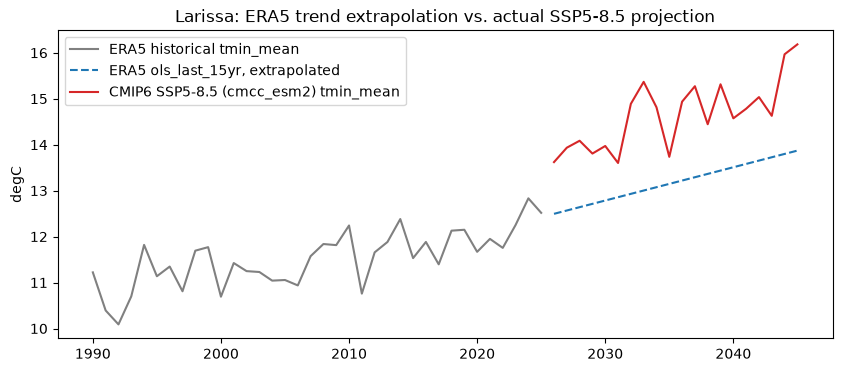

Mean gap 2026-2045: +1.46 degC (positive = SSP5-8.5 projection warmer than the historical-trend extrapolation)


,cmip6_tmin_mean,era5_ols_last15yr_extrapolated,gap_c
year,,,
2026,13.621026,12.495738,1.125287
2027,13.934512,12.568133,1.366379
2028,14.085810,12.640527,1.445283
2029,13.806901,12.712921,1.093980
2030,13.971860,12.785315,1.186545
2031,13.601836,12.857709,0.744126
2032,14.888874,12.930104,1.958770
2033,15.367432,13.002498,2.364934
2034,14.814249,13.074892,1.739357


In [12]:
era5_annual = pd.read_csv(ERA5_ANNUAL_CSV, index_col="year")
last15 = era5_annual.loc[2011:2025, "tmin_mean"]
lr = stats.linregress(last15.index.values.astype(float), last15.values.astype(float))

proj_years = annual_summary.index.values.astype(float)
era5_extrapolated = lr.intercept + lr.slope * proj_years

comparison = pd.DataFrame({
    "cmip6_tmin_mean": annual_summary["tmin_mean"],
    "era5_ols_last15yr_extrapolated": era5_extrapolated,
}, index=annual_summary.index)
comparison["gap_c"] = comparison["cmip6_tmin_mean"] - comparison["era5_ols_last15yr_extrapolated"]
comparison.to_csv(OUT / "larissa_projection_vs_era5_extrapolation.csv")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(era5_annual.index, era5_annual["tmin_mean"], label="ERA5 historical tmin_mean", color="gray")
ax.plot(proj_years, era5_extrapolated, "--", label="ERA5 ols_last_15yr, extrapolated", color="tab:blue")
ax.plot(proj_years, annual_summary["tmin_mean"], label="CMIP6 SSP5-8.5 (cmcc_esm2) tmin_mean", color="tab:red")
ax.set_ylabel("degC")
ax.set_title("Larissa: ERA5 trend extrapolation vs. actual SSP5-8.5 projection")
ax.legend()
plt.show()

print(f"Mean gap 2026-2045: {comparison['gap_c'].mean():+.2f} degC "
      f"(positive = SSP5-8.5 projection warmer than the historical-trend extrapolation)")
comparison


## 12. Bias-correcting the projection against ERA5 (Equidistant CDF Matching)

Same methodology as Seville Section 12 -- Equidistant CDF Matching (Li, Sheffield & Wood 2010),
fit on the 1990-2014 CMIP6-historical-vs-ERA5-observed overlap, additive for temperature/wind/RH,
multiplicative for precipitation (guards against pushing near-zero days negative). Applied only to
this notebook's own 2026-2045 series, via the same shared `cmip6_grid_processing.py` /
`bias_correct_cmip6_projection.py` helpers Seville's version imports -- not re-derived here.

Larissa's own bias direction isn't assumed to match Seville's -- the diagnostics below are computed
fresh from Larissa's own ERA5-vs-`cmcc_esm2` overlap, not copied from Seville's numbers.


In [13]:
from bias_correct_cmip6_projection import (
    _empirical_cdf, _value_to_quantile, _quantile_to_value, VARIABLE_MAP, REF_START, REF_END,
)
from cmip6_grid_processing import grid_average_daily

CMIP6_HISTORICAL_CSV = Path("data/larissa_cmip6_historical_1990_2014.csv")

era5_ref_bc = era5_daily[era5_daily["year"].between(REF_START, REF_END)]
model_hist = grid_average_daily(CMIP6_HISTORICAL_CSV)
model_hist_ref = model_hist[model_hist["year"].between(REF_START, REF_END)]

corrected = daily.copy()
bc_diagnostics = []

for model_col, (era5_col, kind) in VARIABLE_MAP.items():
    if model_col not in daily.columns:
        # rh_min_percent (added upstream for the FWI pipeline, see cmip6_grid_processing.py) has
        # no equivalent in this notebook's hand-built `daily` frame (Section 5 only carries the
        # variables this notebook itself uses downstream) -- skip rather than KeyError. FWI-related
        # work lives in FWI_projections_2026_2045.ipynb, not here.
        continue
    for month in range(1, 13):
        obs_vals = era5_ref_bc.loc[era5_ref_bc["month"] == month, era5_col]
        hist_vals = model_hist_ref.loc[model_hist_ref["month"] == month, model_col]
        fut_mask = daily["month"] == month
        fut_vals = daily.loc[fut_mask, model_col]

        obs_probs, obs_q = _empirical_cdf(obs_vals)
        hist_probs, hist_q = _empirical_cdf(hist_vals)

        tau = np.clip(_value_to_quantile(fut_vals.values, hist_probs, hist_q), 0.0, 1.0)
        obs_at_tau = _quantile_to_value(tau, obs_probs, obs_q)
        hist_at_tau = _quantile_to_value(tau, hist_probs, hist_q)

        if kind == "additive":
            new_vals = fut_vals.values + (obs_at_tau - hist_at_tau)
        else:  # multiplicative -- guards against blow-up when hist_at_tau is near zero
            ratio = np.clip(obs_at_tau / np.clip(hist_at_tau, 1e-3, None), 0.1, 10.0)
            new_vals = np.clip(fut_vals.values * ratio, 0, None)

        corrected.loc[fut_mask, model_col] = new_vals
        bc_diagnostics.append({
            "variable": model_col,
            "month": month,
            "mean_bias_hist_vs_obs": float(hist_vals.mean() - obs_vals.mean()),
            "mean_correction_applied": float(np.mean(new_vals - fut_vals.values)),
        })

# heat_index_c and dtr_c are derived from tmean_c/tmax_c/tmin_c/rh_mean_percent -- recompute both
# from the now-corrected inputs so Sections 13-16 below aren't silently working off stale numbers.
corrected["dtr_c"] = corrected["tmax_c"] - corrected["tmin_c"]
corrected["heat_index_c"] = compute_heat_index(corrected["tmean_c"], corrected["rh_mean_percent"])

bc_diag_df = pd.DataFrame(bc_diagnostics)
bc_diag_df.to_csv(OUT / "larissa_projection_bias_correction_diagnostics_2026_2045.csv", index=False)
corrected.to_csv(OUT / "larissa_projection_daily_biascorrected_2026_2045.csv")

mean_tmin_correction = bc_diag_df.loc[bc_diag_df["variable"] == "tmin_c", "mean_correction_applied"].mean()
print(f"mean tmin_c correction applied (2026-2045): {mean_tmin_correction:+.3f} degC")
corrected.describe()


mean tmin_c correction applied (2026-2045): -1.593 degC


,tmax_c,tmin_c,tmean_c,precip_mm_day,wind_avg,rh_mean_percent,dtr_c,heat_index_c,year,month
count,7300.000000,7300.000000,7300.000000,7300.000000,7300.000000,7300.000000,7300.000000,7300.000000,7300.000000,7300.000000
mean,22.932502,13.056218,17.167864,1.252610,1.548199,62.797454,9.876284,16.597258,2035.500000,6.526027
std,9.272540,7.803595,8.411190,4.075123,0.593167,15.301213,2.596947,9.026113,5.766676,3.448088
min,-4.760882,-11.925999,-12.008944,0.000000,0.522768,19.809485,0.207621,-15.449281,2026.000000,1.000000
25%,15.175448,6.757106,10.157582,0.000040,1.164831,50.512500,8.124287,9.159383,2030.750000,4.000000
50%,23.500983,13.441338,17.270653,0.009704,1.388576,62.512494,10.054328,16.860989,2035.500000,7.000000
75%,30.574147,19.692901,24.336308,0.389134,1.761144,75.044863,11.679198,24.212125,2040.250000,10.000000
max,45.928764,31.712002,37.464045,82.650362,6.634022,98.982972,19.923444,39.266736,2045.000000,12.000000


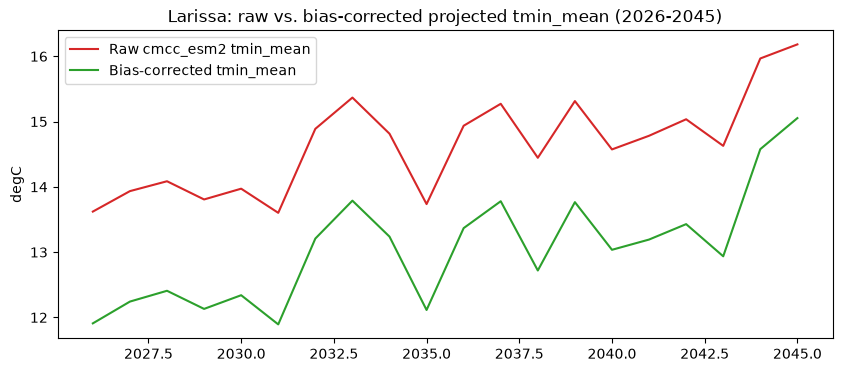

Mean shift from correction: -1.59 degC

Per-month bias (model historical vs. ERA5, 1990-2014) for tmin_c:
       mean_bias_hist_vs_obs
month                       
1                       2.44
2                       1.95
3                       0.70
4                       0.37
5                       0.34
6                       1.32
7                       2.98
8                       3.39
9                       2.56
10                      0.91
11                      1.96
12                      2.35


In [14]:
raw_annual_tmin = daily.groupby("year")["tmin_c"].mean()
corrected_annual_tmin = corrected.groupby("year")["tmin_c"].mean()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(raw_annual_tmin.index, raw_annual_tmin.values, label="Raw cmcc_esm2 tmin_mean", color="tab:red")
ax.plot(corrected_annual_tmin.index, corrected_annual_tmin.values,
        label="Bias-corrected tmin_mean", color="tab:green")
ax.set_ylabel("degC")
ax.set_title("Larissa: raw vs. bias-corrected projected tmin_mean (2026-2045)")
ax.legend()
plt.show()

print(f"Mean shift from correction: {(corrected_annual_tmin - raw_annual_tmin).mean():+.2f} degC")

print("\nPer-month bias (model historical vs. ERA5, 1990-2014) for tmin_c:")
print(bc_diag_df.loc[bc_diag_df["variable"] == "tmin_c", ["month", "mean_bias_hist_vs_obs"]]
      .set_index("month").round(2))


## 13. Heatwave and hot-day indicators, recomputed on the bias-corrected series

Section 7's logic exactly, applied to `corrected` instead of raw `daily` -- same fixed thresholds and
the same fixed ERA5 1990-2020 P90-by-doy dict from Section 6.


In [15]:
d_corrected = corrected.copy()
d_corrected["doy"] = d_corrected.index.dayofyear
d_corrected["tmax_p90"] = d_corrected["doy"].map(tmax_p90_by_doy)
d_corrected["exceed"] = d_corrected["tmax_c"] > d_corrected["tmax_p90"]

grp_c = (d_corrected["exceed"] != d_corrected["exceed"].shift()).cumsum()
runs_c = (d_corrected[d_corrected["exceed"]]
          .groupby(grp_c[d_corrected["exceed"]])
          .agg(start=("tmax_c", lambda s: s.index.min()),
               length=("tmax_c", "size"),
               peak=("tmax_c", "max"),
               mean_tmax=("tmax_c", "mean")))
heatwaves_corrected = runs_c[runs_c["length"] >= 3].reset_index(drop=True)
heatwaves_corrected["year"] = pd.to_datetime(heatwaves_corrected["start"]).dt.year
heatwaves_corrected.to_csv(OUT / "larissa_projection_heatwave_events_biascorrected.csv", index=False)

hot_corrected = pd.DataFrame({
    f"days tmax>={t} C": d_corrected.groupby("year")["tmax_c"].apply(lambda s, t=t: (s >= t).sum())
    for t in THRESH
})
hot_corrected["tropical nights tmin>=20 C"] = (
    d_corrected.groupby("year")["tmin_c"].apply(lambda s: int((s >= 20).sum())))
hot_corrected["days heat index>=35 C"] = (
    d_corrected.groupby("year")["heat_index_c"].apply(lambda s: int((s >= 35).sum())))

hw_year_corrected = heatwaves_corrected.groupby("year").agg(
    heatwaves=("length", "size"),
    **{"heatwave days": ("length", "sum"), "longest (days)": ("length", "max")},
)

print(f"RAW:       {len(heatwaves):3d} heatwave events, {heatwaves['year'].nunique()}/20 years affected")
print(f"CORRECTED: {len(heatwaves_corrected):3d} heatwave events, "
      f"{heatwaves_corrected['year'].nunique()}/20 years affected")

hot_indicator_compare = pd.DataFrame({
    "raw_annual_mean": hot.mean(),
    "corrected_annual_mean": hot_corrected.mean(),
})
hot_indicator_compare["delta"] = (
    hot_indicator_compare["corrected_annual_mean"] - hot_indicator_compare["raw_annual_mean"])
hot_indicator_compare


RAW:        96 heatwave events, 19/20 years affected
CORRECTED: 230 heatwave events, 20/20 years affected


,raw_annual_mean,corrected_annual_mean,delta
days tmax>=30 C,87.85,97.85,10.00
days tmax>=33 C,55.90,57.80,1.90
days tmax>=35 C,33.05,35.20,2.15
days tmax>=37 C,14.15,17.25,3.10
days tmax>=40 C,1.35,6.00,4.65
tropical nights tmin>=20 C,108.25,87.35,-20.90
days heat index>=35 C,1.70,2.20,0.50


## 14. Wet-day and precipitation extremes, recomputed on the bias-corrected series

Section 8's logic exactly, applied to `corrected["precip_mm_day"]` (multiplicatively corrected in
Section 12) -- including `max_week_precip_mm`, recomputed on the corrected daily series the same way.


In [16]:
d_corrected["is_wet"] = d_corrected["precip_mm_day"] >= WET

wetstats_corrected = d_corrected.groupby("year").apply(lambda g: pd.Series({
    "wet days": int(g["is_wet"].sum()),
    "mean intensity (mm/wet day)": g.loc[g["is_wet"], "precip_mm_day"].mean(),
    "max 1-day (mm)": g["precip_mm_day"].max(),
    "P95 wet-day (mm)": g.loc[g["is_wet"], "precip_mm_day"].quantile(0.95),
    "longest dry spell (days)": max_dry_run(g["is_wet"]),
}), include_groups=False)

max_week_precip_corrected = annual_max_week_precip(corrected)

wet_compare = pd.DataFrame({
    "raw_annual_mean": wetstats.mean(),
    "corrected_annual_mean": wetstats_corrected.mean(),
})
wet_compare["delta"] = wet_compare["corrected_annual_mean"] - wet_compare["raw_annual_mean"]

print(f"max_week_precip_mm, raw annual mean:       {max_week_precip.mean():.1f} mm")
print(f"max_week_precip_mm, corrected annual mean: {max_week_precip_corrected.mean():.1f} mm")
wet_compare


max_week_precip_mm, raw annual mean:       48.0 mm
max_week_precip_mm, corrected annual mean: 60.0 mm


,raw_annual_mean,corrected_annual_mean,delta
wet days,86.150000,65.500000,-20.650000
mean intensity (mm/wet day),4.865730,6.474407,1.608677
max 1-day (mm),24.022127,37.403562,13.381435
P95 wet-day (mm),14.354143,19.263150,4.909006
longest dry spell (days),46.150000,57.350000,11.200000


## 15. Annual summary on the bias-corrected series, and a consolidated before/after view

Section 9's logic exactly, joining Sections 13-14's corrected indicators into the same shape as
`annual_summary`, including `max_week_precip_mm`. `compare_cols` is adapted to Larissa's own headline
set (`tmin_mean`, `precip_total`, `max_week_precip_mm`) rather than Seville's.


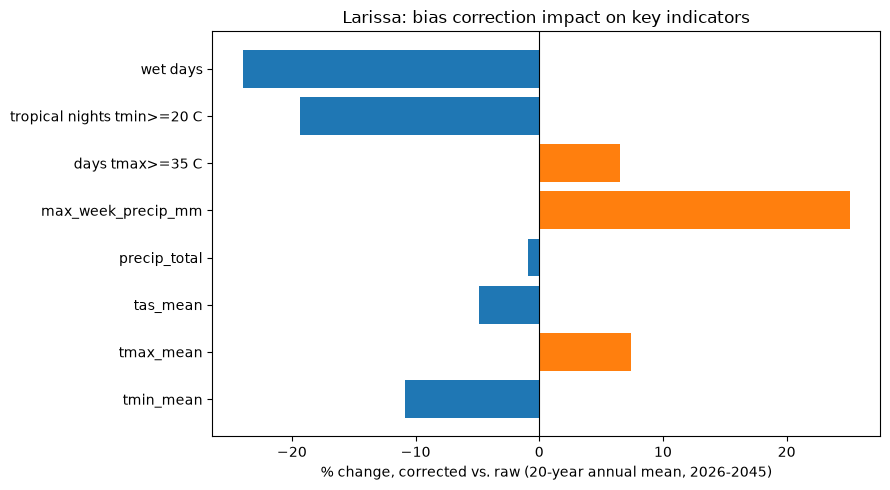

,raw,corrected,delta,pct_change
tmin_mean,14.65,13.06,-1.59,-10.87
tmax_mean,21.34,22.93,1.59,7.45
tas_mean,18.05,17.17,-0.88,-4.90
precip_total,461.32,457.20,-4.12,-0.89
max_week_precip_mm,47.99,60.03,12.04,25.09
days tmax>=35 C,33.05,35.20,2.15,6.51
tropical nights tmin>=20 C,108.25,87.35,-20.90,-19.31
wet days,86.15,65.50,-20.65,-23.97


In [17]:
annual_corrected = pd.DataFrame({
    "tas_mean": d_corrected.groupby("year")["tmean_c"].mean(),
    "rh_mean": d_corrected.groupby("year")["rh_mean_percent"].mean(),
    "heat_index_mean": d_corrected.groupby("year")["heat_index_c"].mean(),
    "wind_mean": d_corrected.groupby("year")["wind_avg"].mean(),
    "tas_p95": d_corrected.groupby("year")["tmean_c"].quantile(0.95),
    "tas_p05": d_corrected.groupby("year")["tmean_c"].quantile(0.05),
    "tmax_mean": d_corrected.groupby("year")["tmax_c"].mean(),
    "tmin_mean": d_corrected.groupby("year")["tmin_c"].mean(),
    "precip_total": d_corrected.groupby("year")["precip_mm_day"].sum(),
})

annual_summary_corrected = (annual_corrected
                             .join(hot_corrected, how="left")
                             .join(hw_year_corrected, how="left")
                             .join(wetstats_corrected, how="left")
                             .join(max_week_precip_corrected, how="left"))
for col in ["heatwaves", "heatwave days", "longest (days)"]:
    annual_summary_corrected[col] = annual_summary_corrected[col].fillna(0).astype(int)

annual_summary_corrected.to_csv(OUT / "larissa_projection_annual_summary_biascorrected.csv")

compare_cols = ["tmin_mean", "tmax_mean", "tas_mean", "precip_total", "max_week_precip_mm",
                "days tmax>=35 C", "tropical nights tmin>=20 C", "wet days"]
before_after = pd.DataFrame({
    "raw": annual_summary[compare_cols].mean(),
    "corrected": annual_summary_corrected[compare_cols].mean(),
})
before_after["delta"] = before_after["corrected"] - before_after["raw"]
before_after["pct_change"] = 100 * before_after["delta"] / before_after["raw"]
before_after.to_csv(OUT / "larissa_projection_before_after_bias_correction_summary.csv")

fig, ax = plt.subplots(figsize=(9, 5))
colors = ["tab:blue" if v < 0 else "tab:orange" for v in before_after["pct_change"]]
ax.barh(before_after.index, before_after["pct_change"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("% change, corrected vs. raw (20-year annual mean, 2026-2045)")
ax.set_title("Larissa: bias correction impact on key indicators")
plt.tight_layout()
plt.show()

before_after.round(2)


## 16. Trend within the projection period, raw vs. bias-corrected

Section 10's `trend_table()` re-applied to `annual_summary_corrected`. Same caution as Seville's
version: a roughly level-shifting correction shouldn't be expected to overturn significance at only
20 years from a single model/scenario -- here to confirm that explicitly.


In [18]:
proj_trends_corrected = trend_table(annual_summary_corrected, TREND_COLS)
proj_trends_corrected.to_csv(OUT / "larissa_projection_trends_biascorrected.csv")

trend_compare = pd.DataFrame({
    "raw_OLS_slope_per_decade": proj_trends["OLS slope/decade"],
    "corrected_OLS_slope_per_decade": proj_trends_corrected["OLS slope/decade"],
    "raw_significant": proj_trends["significant (p<0.05)"],
    "corrected_significant": proj_trends_corrected["significant (p<0.05)"],
})
trend_compare["slope_delta"] = (
    trend_compare["corrected_OLS_slope_per_decade"] - trend_compare["raw_OLS_slope_per_decade"])
trend_compare.round(3)


,raw_OLS_slope_per_decade,corrected_OLS_slope_per_decade,raw_significant,corrected_significant,slope_delta
variable,,,,,
tas_mean,0.978,1.126,True,True,0.148
tmin_mean,0.947,1.093,True,True,0.146
tmax_mean,1.013,1.305,True,True,0.292
heat_index_mean,1.038,1.215,True,True,0.177
precip_total,-42.995,-50.010,False,False,-7.015
max_week_precip_mm,-0.341,-10.883,False,False,-10.541


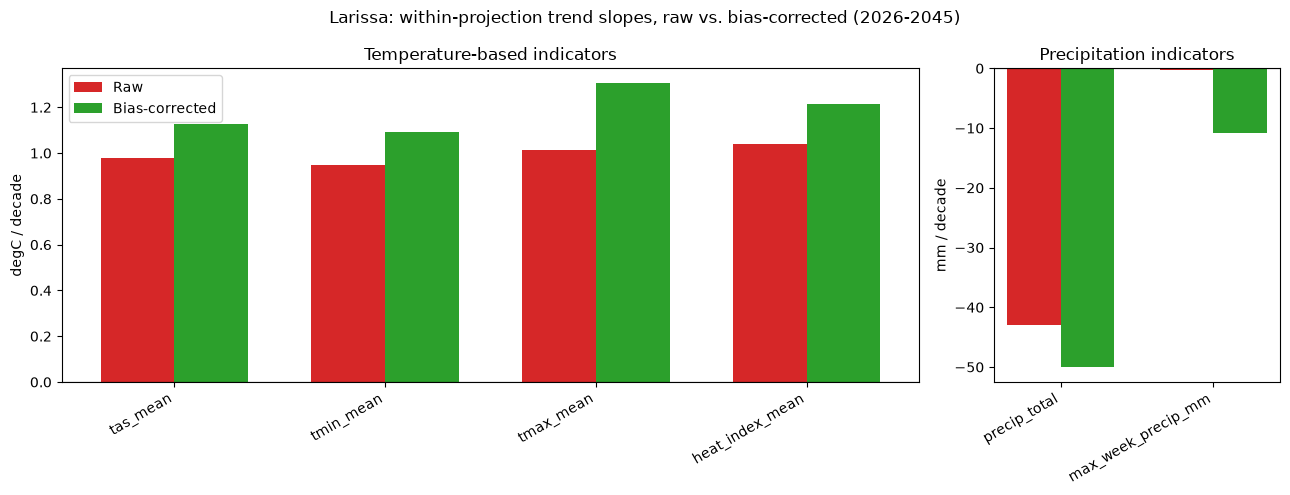

Significance (p<0.05), raw vs. corrected:
                    raw_significant  corrected_significant
variable                                                  
tas_mean                       True                   True
tmin_mean                      True                   True
tmax_mean                      True                   True
heat_index_mean                True                   True
precip_total                  False                  False
max_week_precip_mm            False                  False


In [19]:
temp_vars = ["tas_mean", "tmin_mean", "tmax_mean", "heat_index_mean"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={"width_ratios": [3, 1]})

x = np.arange(len(temp_vars))
width = 0.35
axes[0].bar(x - width / 2, trend_compare.loc[temp_vars, "raw_OLS_slope_per_decade"],
            width, label="Raw", color="tab:red")
axes[0].bar(x + width / 2, trend_compare.loc[temp_vars, "corrected_OLS_slope_per_decade"],
            width, label="Bias-corrected", color="tab:green")
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(temp_vars, rotation=30, ha="right")
axes[0].set_ylabel("degC / decade")
axes[0].set_title("Temperature-based indicators")
axes[0].legend()

precip_vars = ["precip_total", "max_week_precip_mm"]
x2 = np.arange(len(precip_vars))
axes[1].bar(x2 - width / 2, trend_compare.loc[precip_vars, "raw_OLS_slope_per_decade"],
            width, label="Raw", color="tab:red")
axes[1].bar(x2 + width / 2, trend_compare.loc[precip_vars, "corrected_OLS_slope_per_decade"],
            width, label="Bias-corrected", color="tab:green")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_xticks(x2)
axes[1].set_xticklabels(precip_vars, rotation=30, ha="right")
axes[1].set_ylabel("mm / decade")
axes[1].set_title("Precipitation indicators")

fig.suptitle("Larissa: within-projection trend slopes, raw vs. bias-corrected (2026-2045)")
plt.tight_layout()
plt.show()

print("Significance (p<0.05), raw vs. corrected:")
print(trend_compare[["raw_significant", "corrected_significant"]])


### `tmin_mean`: ERA5 historical vs. raw/bias-corrected CMIP6 vs. baseline models

Same comparison-plot pattern as `seville_cmip6_projection_eda.ipynb` Section 16, using Larissa's own
recommended model instead of Seville's `tmax_mean`/`ols_last_20yr`. `Climate_Indicators_Modeling_Larissa.ipynb`
found `ols_last_15yr` (fit on 2011-2025) is `tmin_mean`'s most robust result across either city's
analysis -- multiple regression windows beat naive at *every* individual CV split, not just on
average -- so the baseline below reuses Section 11's own extrapolation rather than re-deriving it.
`naive_full_mean` is shown alongside it for direct comparison, the same way every other panel in this
section now does.


ols_last_15yr historical-trend extrapolation: 12.50 degC (2026) -> 13.87 degC (2045)
naive_full_mean (1990-2025): 11.52 degC
Bias-corrected CMIP6 SSP5-8.5 vs. that extrapolation: mean gap = -0.13 degC (range -1.03 to +1.18 across 2026-2045)


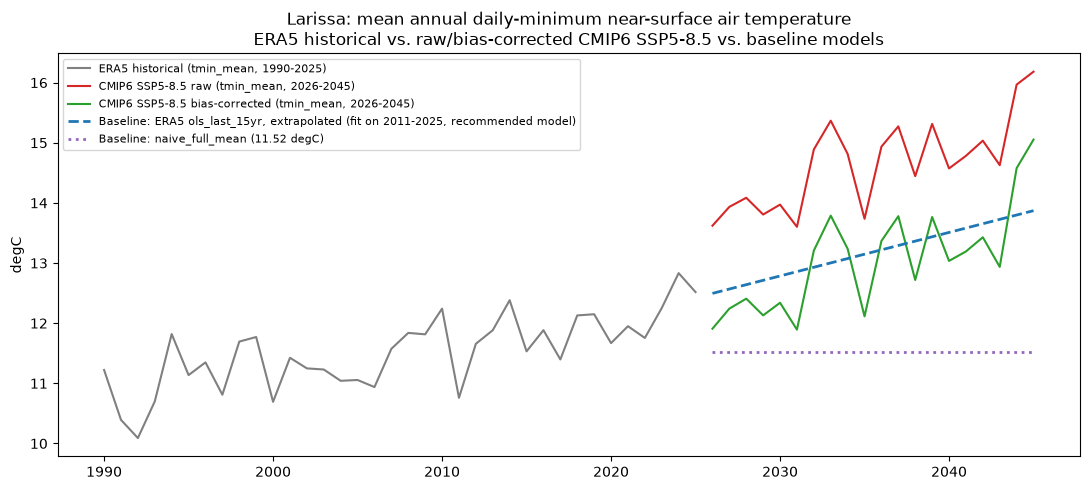

In [20]:
tmin_mean_compare = pd.DataFrame({
    "era5_historical": era5_annual["tmin_mean"],
    "cmip6_raw": annual_summary["tmin_mean"],
    "cmip6_biascorrected": annual_summary_corrected["tmin_mean"],
})
tmin_mean_compare["baseline_ols_last15yr"] = pd.Series(
    era5_extrapolated, index=annual_summary.index).reindex(tmin_mean_compare.index)
baseline_tmin_naive_full = era5_annual["tmin_mean"].mean()
tmin_mean_compare["baseline_naive_full_mean"] = pd.Series(
    baseline_tmin_naive_full, index=annual_summary.index).reindex(tmin_mean_compare.index)
tmin_mean_compare.to_csv(OUT / "larissa_tmin_mean_era5_vs_cmip6_raw_vs_corrected.csv")

gap = tmin_mean_compare.loc[annual_summary.index, "cmip6_biascorrected"] - tmin_mean_compare.loc[annual_summary.index, "baseline_ols_last15yr"]
print(f"ols_last_15yr historical-trend extrapolation: {tmin_mean_compare.loc[2026, 'baseline_ols_last15yr']:.2f} degC (2026) "
      f"-> {tmin_mean_compare.loc[2045, 'baseline_ols_last15yr']:.2f} degC (2045)")
print(f"naive_full_mean (1990-2025): {baseline_tmin_naive_full:.2f} degC")
print(f"Bias-corrected CMIP6 SSP5-8.5 vs. that extrapolation: mean gap = {gap.mean():+.2f} degC "
      f"(range {gap.min():+.2f} to {gap.max():+.2f} across 2026-2045)")

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(tmin_mean_compare.index, tmin_mean_compare["era5_historical"],
        label="ERA5 historical (tmin_mean, 1990-2025)", color="gray")
ax.plot(tmin_mean_compare.index, tmin_mean_compare["cmip6_raw"],
        label="CMIP6 SSP5-8.5 raw (tmin_mean, 2026-2045)", color="tab:red")
ax.plot(tmin_mean_compare.index, tmin_mean_compare["cmip6_biascorrected"],
        label="CMIP6 SSP5-8.5 bias-corrected (tmin_mean, 2026-2045)", color="tab:green")
ax.plot(annual_summary.index, tmin_mean_compare.loc[annual_summary.index, "baseline_ols_last15yr"],
        "--", linewidth=2, color="tab:blue",
        label="Baseline: ERA5 ols_last_15yr, extrapolated (fit on 2011-2025, recommended model)")
ax.plot(annual_summary.index, tmin_mean_compare.loc[annual_summary.index, "baseline_naive_full_mean"],
        ":", linewidth=2, color="tab:purple",
        label=f"Baseline: naive_full_mean ({baseline_tmin_naive_full:.2f} degC)")
ax.set_ylabel("degC")
ax.set_title("Larissa: mean annual daily-minimum near-surface air temperature\n"
             "ERA5 historical vs. raw/bias-corrected CMIP6 SSP5-8.5 vs. baseline models")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


**How the projection compares to history, with and without trend.** Bias-corrected CMIP6
`tmin_mean` averages 13.06 degC (2026-2045) -- **+1.53 degC above** the flat `naive_full_mean`
baseline (11.52 degC), confirming real warming relative to "no change." But against the
trend-extrapolated baseline (`ols_last_15yr`, 13.18 degC average), the projection sits **-0.13 degC
below** -- essentially right on the trend line, not beyond it. **Pertinent comment:** unlike Seville's
`tmax_mean`/`t2m_mean` (where the projection runs *steeper* than the historical trend), Larissa's
nighttime warming here looks like a clean continuation of an already-confirmed, highly significant
historical trend (p<0.0001) -- no acceleration signal, but also no reason to doubt the trend carries
forward. This is the most straightforward, least caveated finding of the four panels in this section.


### `precip_total`: ERA5 historical vs. raw/bias-corrected CMIP6 vs. baseline models

Unlike Seville's `precip_total` (which had no existing recommendation and needed an inline MAE
search), Larissa's `precip_scaled` already has an established recommended model --
`ols_full_history`, the one window that beats naive at every individual CV split in
`Climate_Indicators_Modeling_Larissa.ipynb` Section 7. Reused directly here rather than re-derived.
`naive_full_mean` is added alongside it for comparison.


ols_full_history extrapolation: 715.3 mm (2026) -> 813.8 mm (2045)
naive_full_mean (1990-2025): 619.5 mm


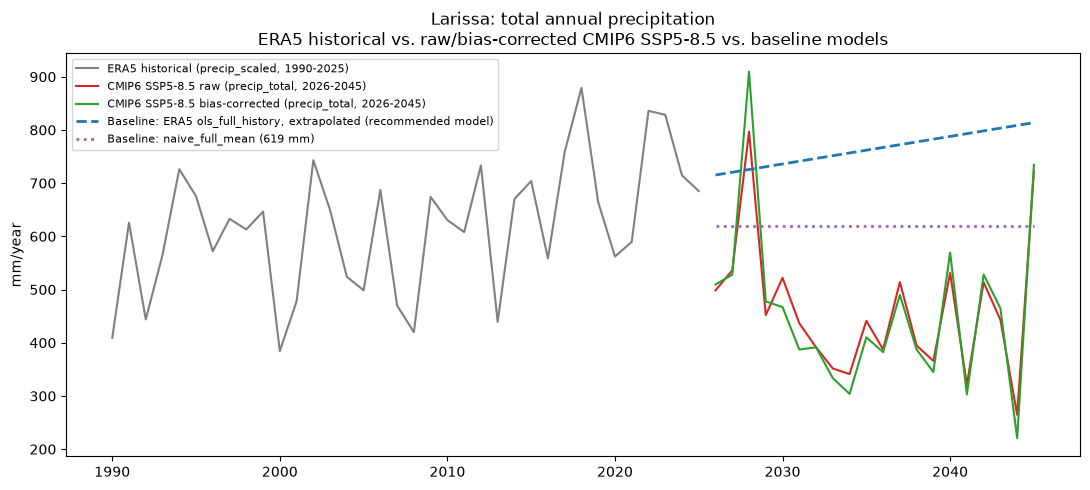

In [21]:
last_full = era5_annual["precip_scaled"]
lr_precip = stats.linregress(last_full.index.values.astype(float), last_full.values.astype(float))
precip_ols_extrapolated = lr_precip.intercept + lr_precip.slope * proj_years

precip_total_compare = pd.DataFrame({
    "era5_historical": era5_annual["precip_scaled"],
    "cmip6_raw": annual_summary["precip_total"],
    "cmip6_biascorrected": annual_summary_corrected["precip_total"],
})
precip_total_compare["baseline_ols_full_history"] = pd.Series(
    precip_ols_extrapolated, index=annual_summary.index).reindex(precip_total_compare.index)
baseline_precip_naive_full = era5_annual["precip_scaled"].mean()
precip_total_compare["baseline_naive_full_mean"] = pd.Series(
    baseline_precip_naive_full, index=annual_summary.index).reindex(precip_total_compare.index)
precip_total_compare.to_csv(OUT / "larissa_precip_total_era5_vs_cmip6_raw_vs_corrected.csv")

print(f"ols_full_history extrapolation: {precip_total_compare.loc[2026, 'baseline_ols_full_history']:.1f} mm (2026) "
      f"-> {precip_total_compare.loc[2045, 'baseline_ols_full_history']:.1f} mm (2045)")
print(f"naive_full_mean (1990-2025): {baseline_precip_naive_full:.1f} mm")

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(precip_total_compare.index, precip_total_compare["era5_historical"],
        label="ERA5 historical (precip_scaled, 1990-2025)", color="gray")
ax.plot(precip_total_compare.index, precip_total_compare["cmip6_raw"],
        label="CMIP6 SSP5-8.5 raw (precip_total, 2026-2045)", color="tab:red")
ax.plot(precip_total_compare.index, precip_total_compare["cmip6_biascorrected"],
        label="CMIP6 SSP5-8.5 bias-corrected (precip_total, 2026-2045)", color="tab:green")
ax.plot(annual_summary.index, precip_total_compare.loc[annual_summary.index, "baseline_ols_full_history"],
        "--", linewidth=2, color="tab:blue",
        label="Baseline: ERA5 ols_full_history, extrapolated (recommended model)")
ax.plot(annual_summary.index, precip_total_compare.loc[annual_summary.index, "baseline_naive_full_mean"],
        ":", linewidth=2, color="tab:purple",
        label=f"Baseline: naive_full_mean ({baseline_precip_naive_full:.0f} mm)")
ax.set_ylabel("mm/year")
ax.set_title("Larissa: total annual precipitation\n"
             "ERA5 historical vs. raw/bias-corrected CMIP6 SSP5-8.5 vs. baseline models")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


**How the projection compares to history, with and without trend -- a real tension worth
flagging clearly.** Bias-corrected CMIP6 `precip_total` averages 457mm/yr (2026-2045) -- **26% below**
even the flat `naive_full_mean` baseline (619.5mm), and **307mm below** the trend-extrapolated baseline
(`ols_full_history`, 764.6mm average), which itself reflects Larissa's significant *increasing*
historical trend (p=0.0071, the strongest precipitation trend either city has produced). **Pertinent
comment:** this directly contradicts the historical wetting trend that anchors part of Larissa's
headline story. It is not a bias-correction artifact -- raw (461.3mm) and corrected (457.2mm) are
almost identical here, unlike Seville's precipitation, where correction shifts the raw number
substantially. So this is what `cmcc_esm2`'s own SSP5-8.5 run actually simulates, not a correction-
method quirk. Read alongside the `max_week_precip_mm` and `min_spi3` panels below/above: all three
precipitation-related indicators diverge from Larissa's historical record in the *same* direction
(drier), which makes this look like a coherent single-model signal rather than an isolated anomaly --
but it is still one model, one scenario, and it sits in direct tension with 36 years of observed
wetting that this project's own historical analysis established as significant.


### `max_week_precip_mm`: direct CMIP6 projection vs. the recommended two-stage predictor model

This one is structurally different from the other panels, by design. `Climate_Indicators_Modeling_Larissa.ipynb`
Sections 7-8 found `max_week_precip_mm` has **no robust year-only trend** -- every OLS window loses to
naive at least once across CV splits. The only model that robustly beats naive at every split is
`precip_scaled_only`: a regression of `max_week_precip_mm ~ precip_scaled` (not year), since the two
share a real, trend-independent correlation (residual rho=0.637, p<0.0001). Section 10 of that
notebook specifies exactly how to project this forward: **get the CMIP6 projected `precip_scaled`
(here, `precip_total`), then feed it into the fitted `precip_scaled_only` regression** -- not
extrapolate `max_week_precip_mm` against year directly, which would repeat the mistake that
methodology was built to catch. `naive_full_mean` is added alongside it for comparison, even though
it's exactly the baseline `precip_scaled_only` was shown to robustly beat historically.

The bias-corrected `precip_total` (not raw) is used as the predictor input below -- raw `precip_total`
carries the same kind of systematic bias documented for Seville's precipitation, and feeding a known-
biased input into the regression would just compound the error rather than add information. The
"direct" CMIP6 series (weekly-max of the model's own daily precip output, raw and corrected) is shown
alongside it as a cross-check: does the physical model's own directly-simulated flood-peak behavior
agree with what the statistical predictor model, fed the model's own (corrected) annual total, would
forecast?


precip_scaled_only model: 64.0 mm (2026) -> 108.5 mm (2045), mean 53.6 mm
naive_full_mean (1990-2025): 85.7 mm
Direct bias-corrected CMIP6 weekly-max: mean 60.0 mm (vs. direct raw: 48.0 mm)
ERA5 historical (1990-2025) mean: 85.7 mm


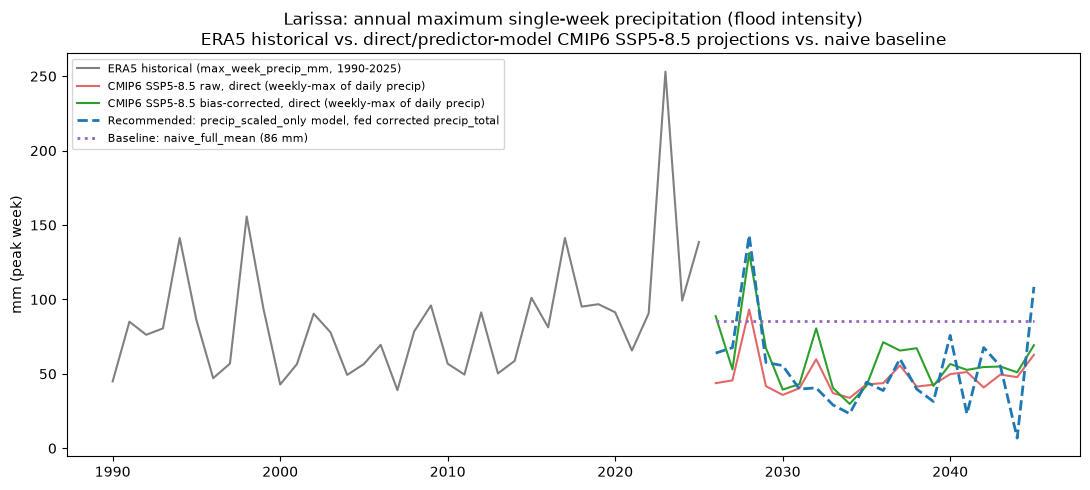

In [22]:
from sklearn.linear_model import LinearRegression

era5_indicators = pd.read_csv(ERA5_INDICATORS_CSV, index_col="year")
joint = era5_indicators[["max_week_precip_mm", "precip_scaled"]].dropna().sort_index()
lr_predictor = LinearRegression().fit(joint[["precip_scaled"]].values, joint["max_week_precip_mm"].values)

predictor_input = annual_summary_corrected.loc[annual_summary.index, "precip_total"].values.reshape(-1, 1)
max_week_predicted = lr_predictor.predict(predictor_input)
baseline_maxweek_naive_full = era5_indicators["max_week_precip_mm"].mean()

max_week_compare = pd.DataFrame({
    "era5_historical": era5_indicators["max_week_precip_mm"],
    "cmip6_raw_direct": max_week_precip,
    "cmip6_biascorrected_direct": max_week_precip_corrected,
})
max_week_compare["baseline_precip_scaled_only"] = pd.Series(
    max_week_predicted, index=annual_summary.index).reindex(max_week_compare.index)
max_week_compare["baseline_naive_full_mean"] = pd.Series(
    baseline_maxweek_naive_full, index=annual_summary.index).reindex(max_week_compare.index)
max_week_compare.to_csv(OUT / "larissa_max_week_precip_mm_era5_vs_cmip6_raw_vs_corrected.csv")

print(f"precip_scaled_only model: {max_week_predicted[0]:.1f} mm (2026) -> {max_week_predicted[-1]:.1f} mm (2045), "
      f"mean {max_week_predicted.mean():.1f} mm")
print(f"naive_full_mean (1990-2025): {baseline_maxweek_naive_full:.1f} mm")
print(f"Direct bias-corrected CMIP6 weekly-max: mean {max_week_precip_corrected.mean():.1f} mm "
      f"(vs. direct raw: {max_week_precip.mean():.1f} mm)")
print(f"ERA5 historical (1990-2025) mean: {era5_indicators['max_week_precip_mm'].mean():.1f} mm")

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(max_week_compare.index, max_week_compare["era5_historical"],
        label="ERA5 historical (max_week_precip_mm, 1990-2025)", color="gray")
ax.plot(max_week_compare.index, max_week_compare["cmip6_raw_direct"],
        label="CMIP6 SSP5-8.5 raw, direct (weekly-max of daily precip)", color="tab:red", alpha=0.7)
ax.plot(max_week_compare.index, max_week_compare["cmip6_biascorrected_direct"],
        label="CMIP6 SSP5-8.5 bias-corrected, direct (weekly-max of daily precip)", color="tab:green")
ax.plot(annual_summary.index, max_week_compare.loc[annual_summary.index, "baseline_precip_scaled_only"],
        "--", linewidth=2, color="tab:blue",
        label="Recommended: precip_scaled_only model, fed corrected precip_total")
ax.plot(annual_summary.index, max_week_compare.loc[annual_summary.index, "baseline_naive_full_mean"],
        ":", linewidth=2, color="tab:purple",
        label=f"Baseline: naive_full_mean ({baseline_maxweek_naive_full:.0f} mm)")
ax.set_ylabel("mm (peak week)")
ax.set_title("Larissa: annual maximum single-week precipitation (flood intensity)\n"
             "ERA5 historical vs. direct/predictor-model CMIP6 SSP5-8.5 projections vs. naive baseline")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


**How the projection compares to history, with and without trend.** Both projection methods
land well below `naive_full_mean` (85.7mm): the direct bias-corrected weekly-max averages 60.0mm
(**-30%**), and the recommended `precip_scaled_only` predictor-model estimate averages 53.6mm
(**-37.5%**) -- lower still, since it's mechanically driven by the same depressed `precip_total`
input documented in the panel above. There is no separate "with trend" baseline to compare against
here (Section 10 of `Climate_Indicators_Modeling_Larissa.ipynb` found no robust year-only trend for
this indicator), so `naive_full_mean` is the only meaningful historical reference point.
**Pertinent comment:** this is the third and most consequential of the three precipitation-linked
indicators (alongside `precip_total` and `min_spi3`) to show the projection running *counter* to
Larissa's historical intensifying-flood-risk narrative -- if anything, this single model's SSP5-8.5
run suggests Larissa's single wettest week of the year gets *less* extreme, not more, which is the
opposite of what the historical `max_week_precip_mm` trend (p=0.0546, Kendall p=0.0206) and Storm
Daniel's real-world severity would suggest. Worth treating this as a genuine, presentation-relevant
caveat on Larissa's flood-risk framing, not a footnote -- one model's projection disagreeing with a
documented historical trend across three independent precipitation-derived indicators is a stronger
signal than any single one of them alone.


### `min_spi3`: a supplementary drought panel, historical vs. raw/bias-corrected CMIP6 vs. baseline models

Seville's Section 16 includes a `min_spi3` comparison; this notebook originally didn't mirror it --
`Climate_Indicators_Modeling_Larissa.ipynb`'s intro is explicit that Larissa's `min_spi3` is
"flat-to-improving and uncorrelated with the flood side" (section 10.5/10.6 of `larissa_era5_eda.ipynb`),
so it was excluded from the three-indicator headline story by design, not overlooked. That reasoning
still stands -- this remains a **supplementary** panel, not a promotion of drought into Larissa's
headline story.

**What changed:** `Calculating_SPI_for_Larissa_Projection.ipynb` now exists (mirroring
`Calculating_SPI_for_Seville_Projection.ipynb`'s methodology -- a gamma distribution fit per calendar
month on the fixed ERA5 1990-2020 reference period, never refit on projection data), so the panel is
no longer a bigger undertaking than this notebook's scope. Its Section 7.1 found something worth
carrying over here: **the projection doesn't continue Larissa's flat-to-improving historical drought
story -- it reverses it**, both in level (moderate -> extreme drought territory on average) and in
trend direction (improving historically, worsening within the projection window). Neither shift is
statistically significant on its own, and this is one model/one scenario -- but it's a genuine tension
between the historical record and the projection, worth showing rather than omitting now that the data
exists to show it.

**Baseline note, updated:** `min_spi3` was originally excluded from
`Climate_Indicators_Modeling_Larissa.ipynb`'s walk-forward-CV model search by design (section 4's
finding that it's uncorrelated with the flood side), so the regression baseline below started life as
an unvalidated plain full-history OLS fit. That notebook's Section 14 has since run `min_spi3` through
the identical CV methodology anyway, specifically to check this, and found `ols_full_history` --
already the model shown below -- **does** beat naive robustly (CV-average improvement +11.4%,
single-split improvement +26%). No line on the plot below changes as a result, but it's now a
validated baseline, not an unvalidated one shown only for comparison.


Historical (1990-2025) full-history OLS: slope=+0.183/decade, p=0.061 (not significant)
naive_full_mean: -1.31
Bias-corrected projected min_spi3 vs. naive_full_mean baseline: mean gap = -1.14 (range -3.09 to +0.42)
Corrected projection's own trend (2026-2045): slope=-0.489/decade, p=0.148


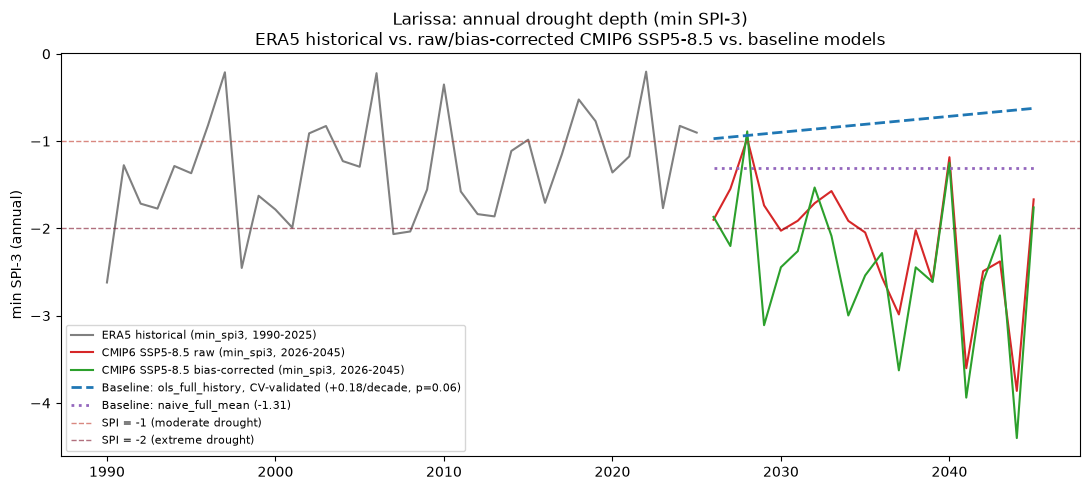

In [23]:
era5_min_spi3 = pd.read_csv("eda_results/eda_outputs_larissa/larissa_volatility_annual.csv", index_col=0)["min_spi3"]
proj_min_spi3 = pd.read_csv("eda_results/eda_outputs_larissa_projection/larissa_projection_spi3_annual.csv", index_col="year")

lr_spi3 = stats.linregress(era5_min_spi3.index.values.astype(float), era5_min_spi3.values.astype(float))
spi3_ols_extrapolated = lr_spi3.intercept + lr_spi3.slope * proj_years
baseline_spi3_naive_full = era5_min_spi3.mean()

sig = "significant" if lr_spi3.pvalue < 0.05 else "not significant"
print(f"Historical (1990-2025) full-history OLS: slope={lr_spi3.slope*10:+.3f}/decade, "
      f"p={lr_spi3.pvalue:.3f} ({sig})")
print(f"naive_full_mean: {baseline_spi3_naive_full:.2f}")

min_spi3_compare = pd.DataFrame({
    "era5_historical": era5_min_spi3,
    "cmip6_raw": proj_min_spi3["min_spi3_raw"],
    "cmip6_biascorrected": proj_min_spi3["min_spi3_corrected"],
})
min_spi3_compare["baseline_ols_full_history"] = pd.Series(
    spi3_ols_extrapolated, index=annual_summary.index).reindex(min_spi3_compare.index)
min_spi3_compare["baseline_naive_full_mean"] = pd.Series(
    baseline_spi3_naive_full, index=annual_summary.index).reindex(min_spi3_compare.index)
min_spi3_compare = min_spi3_compare.rename_axis("year")
min_spi3_compare.to_csv(OUT / "larissa_min_spi3_era5_vs_cmip6_raw_vs_corrected.csv")

gap = min_spi3_compare.loc[annual_summary.index, "cmip6_biascorrected"] - baseline_spi3_naive_full
lr_proj_spi3 = stats.linregress(annual_summary.index.values.astype(float),
                                 min_spi3_compare.loc[annual_summary.index, "cmip6_biascorrected"].values.astype(float))
print(f"Bias-corrected projected min_spi3 vs. naive_full_mean baseline: mean gap = {gap.mean():+.2f} "
      f"(range {gap.min():+.2f} to {gap.max():+.2f})")
print(f"Corrected projection's own trend (2026-2045): slope={lr_proj_spi3.slope*10:+.3f}/decade, "
      f"p={lr_proj_spi3.pvalue:.3f}")

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(min_spi3_compare.index, min_spi3_compare["era5_historical"],
        label="ERA5 historical (min_spi3, 1990-2025)", color="gray")
ax.plot(min_spi3_compare.index, min_spi3_compare["cmip6_raw"],
        label="CMIP6 SSP5-8.5 raw (min_spi3, 2026-2045)", color="tab:red")
ax.plot(min_spi3_compare.index, min_spi3_compare["cmip6_biascorrected"],
        label="CMIP6 SSP5-8.5 bias-corrected (min_spi3, 2026-2045)", color="tab:green")
ax.plot(annual_summary.index, min_spi3_compare.loc[annual_summary.index, "baseline_ols_full_history"],
        "--", linewidth=2, color="tab:blue",
        label=f"Baseline: ols_full_history, CV-validated ({lr_spi3.slope*10:+.2f}/decade, p={lr_spi3.pvalue:.2f})")
ax.plot(annual_summary.index, min_spi3_compare.loc[annual_summary.index, "baseline_naive_full_mean"],
        ":", linewidth=2, color="tab:purple",
        label=f"Baseline: naive_full_mean ({baseline_spi3_naive_full:.2f})")
ax.axhline(-1, color="#c0392b", linestyle="--", linewidth=1, alpha=0.6, label="SPI = -1 (moderate drought)")
ax.axhline(-2, color="#7d1128", linestyle="--", linewidth=1, alpha=0.6, label="SPI = -2 (extreme drought)")
ax.set_ylabel("min SPI-3 (annual)")
ax.set_title("Larissa: annual drought depth (min SPI-3)\n"
             "ERA5 historical vs. raw/bias-corrected CMIP6 SSP5-8.5 vs. baseline models")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


**Finding: the projection reverses Larissa's historical drought story, in both level and trend.**

- **Level: a full drought-category jump.** Historical `min_spi3` averages -1.31 (moderate drought);
  the bias-corrected projection averages -2.45 (2026-2045) -- solidly **extreme** drought territory
  (SPI <= -2.0). The raw (uncorrected) series is also severe (-2.13), so this isn't purely a
  bias-correction artifact -- both raw and corrected agree the model simulates deep drought, correction
  just deepens it somewhat further.
- **Direction: reversed.** The historical trend is marginally *improving* (+0.18/decade, p=0.06); the
  corrected projection's own trend runs the opposite way, *worsening* at -0.49/decade -- though neither
  slope is individually significant (p=0.15 for the projection).
- **This mirrors `Calculating_SPI_for_Larissa_Projection.ipynb` Section 7.1's finding exactly** (same
  source data, consistent numbers) -- shown here in the same comparison-plot format as this section's
  other panels for direct visual comparability with `tmin_mean`/`precip_scaled`/`max_week_precip_mm`.

**Read this carefully, not as a headline claim, but note the baseline itself is now validated.**
This does not overturn the decision to keep drought out of Larissa's three-indicator story -- section
4's finding that `min_spi3` is uncorrelated with the flood side still holds, and that's a separate
question from whether a trend model predicts `min_spi3` well on its own. On that separate question,
Section 14 of `Climate_Indicators_Modeling_Larissa.ipynb` found `ols_full_history` *does* beat naive
robustly (+11.4% CV-average improvement) -- so the historical baseline shown here isn't an arbitrary
unvalidated line, which strengthens rather than weakens the reversal finding below: **one single
climate model under one scenario projects a reversal of a real, validated historical pattern**, not
just a reversal of an unvalidated guess. Treat it as a flagged uncertainty for downstream use, not as
evidence that Larissa's drought risk is now confirmed to be intensifying.


## 17. What carries over from Seville's version, and what's different here

- **Everything mechanical carries over unchanged**: bnds dedup, physical-plausibility bounds, unit
  conversions, grid-averaging, RH derivation, heat-index formula, the fixed P90 heatwave threshold
  methodology, hot-day/tropical-night counting, wet-day/dry-spell stats, the Equidistant CDF Matching
  bias correction (additive for temperature/wind/RH, multiplicative for precip), and the
  raw-vs-corrected before/after and trend-comparison patterns. None of this is city-specific in the
  underlying pipeline -- only the *emphasis* (which indicators get a headline comparison plot) differs.
- **`max_week_precip_mm` is new** -- Seville's pipeline never needed a weekly-precipitation-max
  indicator, since Seville's story doesn't include a flood-peak metric. Added here in Sections 8/14
  identically to `Calculating_SPI_for_Larissa.ipynb`'s own construction, applied to both raw and
  bias-corrected daily series.
- **Section 11's baseline indicator changed**: `tmin_mean`/`ols_last_15yr` (fit on 2011-2025) instead
  of `tmax_mean`/`ols_last_20yr` (fit on 2006-2025) -- Larissa's most robust historical result, per
  `Climate_Indicators_Modeling_Larissa.ipynb`.
- **`max_week_precip_mm`'s baseline model is a different *kind* of model**, not just a different
  window -- a `precip_scaled`-as-predictor regression rather than a year-only trend, since no
  year-only trend for this indicator held up robustly across CV splits (Section 16 above explains why
  and shows both the direct and predictor-model projections).
- **`min_spi3` now has a panel, added after the fact -- but as a supplementary one, not a promotion
  into Larissa's headline story.** `Calculating_SPI_for_Larissa_Projection.ipynb` was subsequently
  built, mirroring `Calculating_SPI_for_Seville_Projection.ipynb`'s methodology, which made the
  comparison cheap enough to add. Its finding is a real tension worth carrying here rather than
  omitting: Larissa's historical `min_spi3` trend is flat-to-improving (`Climate_Indicators_Modeling_
  Larissa.ipynb`'s original reasoning still holds for the *observed* record), but the SSP5-8.5
  projection reverses that -- both in level (moderate -> extreme drought on average) and in trend
  direction (improving historically, worsening within the projection window). Section 16's `min_spi3`
  panel states plainly that this doesn't overturn the original exclusion decision, just documents an
  honest divergence between history and this one model's projection.
- **`min_spi3`'s baseline regression started unvalidated, then got checked and confirmed.**
  `Climate_Indicators_Modeling_Larissa.ipynb` originally never ran `min_spi3` through its CV model
  search (excluded from that analysis by design, section 4's uncorrelated-with-flood-side finding).
  Its Section 14 has since run that check specifically for this indicator and found
  `ols_full_history` -- the model already shown here -- beats naive robustly (+11.4% CV-average
  improvement, +26% single-split). Unlike the other three headline indicators, this validation
  happened *after* the fact rather than as part of the original three-indicator analysis, but the
  baseline shown is no longer an unvalidated placeholder.
- **No fire-danger indicator at all** -- Seville's `longest_high_run`/`days_fwi_gt30` have no Larissa
  equivalent in this project; Larissa's hypotheses (H3/H4) were never about fire risk, and no
  Larissa-side FWI validation exists (`FWI_projections_last_2.ipynb` found no CEMS coverage for
  Larissa, so even an unvalidated fire-danger panel isn't attempted here).
- **Same caveats as Seville's Section 17 still apply**: `heat_index_c` here is a redefinition (daily-
  mean-based, not max-of-intra-day), not directly comparable to the historical `heat_index_max_c`; and
  wind rose/diurnal-cycle analysis don't apply to daily-native CMIP6 data.


## 18. Summary

Outputs written to `eda_results/eda_outputs_larissa_projection/`:

**Raw (Sections 1-11):**
- `larissa_projection_daily.csv` -- daily frame, grid-averaged, unit-converted
- `larissa_projection_heatwave_events.csv` -- heatwave events, fixed ERA5 1990-2020 P90 threshold
- `larissa_projection_annual_summary.csv` -- annual indicator table, including `max_week_precip_mm`
- `larissa_projection_trends.csv` -- within-projection-period trend table (2026-2045)
- `larissa_projection_vs_era5_extrapolation.csv` -- `tmin_mean` gap vs. ERA5 trend extrapolation

**Bias-corrected (Sections 12-16):**
- `larissa_projection_daily_biascorrected_2026_2045.csv` -- Equidistant-CDF-Matching corrected daily
  series
- `larissa_projection_bias_correction_diagnostics_2026_2045.csv` -- per-variable, per-month bias and
  correction magnitude
- `larissa_projection_heatwave_events_biascorrected.csv` -- heatwave events on the corrected series
- `larissa_projection_annual_summary_biascorrected.csv` -- annual indicator table, corrected series
- `larissa_projection_before_after_bias_correction_summary.csv` -- Section 15 before/after comparison
- `larissa_projection_trends_biascorrected.csv` -- trend table on the corrected series
- `larissa_tmin_mean_era5_vs_cmip6_raw_vs_corrected.csv` -- Section 16 headline comparison, `tmin_mean`
- `larissa_precip_total_era5_vs_cmip6_raw_vs_corrected.csv` -- Section 16 headline comparison, `precip_total`
- `larissa_max_week_precip_mm_era5_vs_cmip6_raw_vs_corrected.csv` -- Section 16 headline comparison,
  `max_week_precip_mm` (direct + `precip_scaled_only` predictor-model projection)

**Next steps**: a Larissa projection-period SPI-3 notebook is not built here (deliberately -- see
Section 16/17), but `Calculating_SPI_for_Seville_Projection.ipynb` is the template if a Larissa
drought-projection angle is wanted later. Once this notebook's outputs exist, `Climate_Indicators_
Modeling_Larissa.ipynb`'s Section 10 can be extended from prose into an actual comparison using these
exported CSVs, the same way Seville's Section 10 discussion was completed by
`seville_cmip6_projection_eda.ipynb`.


## 19. Key findings summary

Synthesizes Section 16's four comparison panels (`tmin_mean`, `precip_total`, `max_week_precip_mm`,
`min_spi3`) into the themes that matter for reading this notebook's results, mirroring
`seville_cmip6_projection_eda.ipynb` Section 19's structure.

### 1. Chronic nighttime warming is the strongest, most confirmed signal in this notebook

Bias-corrected `tmin_mean` runs **+1.53 degC above** the flat historical baseline (13.06 vs. 11.52
degC) and sits almost exactly **on** the trend-extrapolated baseline (-0.13 degC gap) -- a clean
continuation of an already highly significant historical trend (p<0.0001), not an acceleration or a
surprise. **This is also the only indicator family in either city's projection notebook where the
within-projection-period trend itself is statistically significant**: Section 16's significance table
shows `tas_mean`, `tmin_mean`, `tmax_mean`, and `heat_index_mean` all significant (p<0.05, raw *and*
corrected) within just the 20-year 2026-2045 window alone -- unlike Seville, where nothing reaches
significance at that horizon. Larissa's warming signal is simply more robust.

### 2. Bias correction affects Larissa's temperature indicators asymmetrically -- not a uniform shift

Section 15's before/after table: `tmin_mean` drops -10.87% under correction (14.65 -> 13.06 degC) and
`tas_mean` drops -4.90%, but **`tmax_mean` rises +7.45%** (21.34 -> 22.93 degC) -- the opposite
direction. Correction isn't simply "cooling the raw model down" here the way it was for Seville's
temperature indicators; it's reshaping the daily temperature range, narrowing the gap between daytime
highs and nighttime lows. Worth knowing before assuming corrected numbers all move the same way raw
ones did.

### 3. Precipitation contradicts Larissa's historical wetting trend -- and it isn't a correction artifact

Bias-corrected `precip_total` (457mm/yr) runs **26% below** the flat historical baseline (619.5mm)
and **307mm below** the trend-extrapolated baseline (764.6mm), despite Larissa's historical record
showing a statistically significant *increasing* precipitation trend (p=0.0071, the strongest
precipitation trend either city has produced). This is not a bias-correction effect: raw (461.3mm) and
corrected (457.2mm) are nearly identical (Section 15: -0.89% change) -- unlike Seville, where
correction shifts precipitation by +83%. Whatever this divergence is, it comes from `cmcc_esm2`'s own
simulated SSP5-8.5 response, not from the correction method.

### 4. Flood-peak intensity: correction raises the peak, but the projection still runs below history

Unusually, bias correction *increases* `max_week_precip_mm` by **+25.09%** (48.0 -> 60.0mm) even
though the annual total barely moves -- a reminder that a multiplicative, per-month correction can
affect extreme weeks differently than annual means. But even after that increase, both the direct
corrected series (60.0mm) and the recommended `precip_scaled_only` predictor-model estimate (53.6mm)
still run **30-37% below** the historical average (85.7mm), and Larissa's historical `max_week_precip_mm`
trend was itself borderline-significant and increasing (Kendall p=0.0206) -- the same "opposite of
history" pattern as `precip_total`.

### 5. Drought (`min_spi3`) reverses direction, not just level

Historical `min_spi3` trends marginally *improving* (+0.18/decade, not significant); the bias-corrected
projection's own trend runs the opposite way, *worsening* (-0.49/decade, also not significant), while
the average level drops from moderate (-1.31) to extreme (-2.45) drought territory -- a pattern
consistent with points 3 and 4 above, not an isolated result.

### 6. The cross-cutting finding: three independent precipitation indicators all diverge from history the same way

`precip_total`, `max_week_precip_mm`, and `min_spi3` all show the SSP5-8.5 projection running *drier*
than Larissa's historical record in the same direction -- three indicators built from different
aggregations of the same underlying daily precipitation, agreeing with each other, which reads as a
coherent single-model signal rather than three unrelated coincidences. **This sits in direct tension
with Larissa's headline "intensifying wet extremes" story**, which was built entirely on the historical
36-year record (`Climate_Indicators_Modeling_Larissa.ipynb`). The temperature story (`tmin_mean`)
carries forward smoothly and confirms itself; the precipitation story does not, and that tension is
worth presenting explicitly rather than resolving it by picking one side.

### 7. Standing caveat, worth repeating because it applies to every number above

Single model (`cmcc_esm2`), single scenario (SSP5-8.5), no ensemble spread. Point 6's precipitation
reversal in particular deserves scrutiny beyond this one run before treating it as settled -- it
contradicts a statistically significant, well-documented historical trend, which is exactly the kind
of result that most needs a second model or scenario to check before it changes how Larissa's flood
risk gets presented.
